In [18]:
# configuração para não exibir os warnings
import warnings
warnings.filterwarnings("ignore")

# Imports necessários
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Link para os vinhos
urls_vinhos = [
    'https://raw.githubusercontent.com/kathleenborges/machine-learning-wine-quality/refs/heads/main/winequality-red.csv',
    'https://raw.githubusercontent.com/kathleenborges/machine-learning-wine-quality/refs/heads/main/winequality-white.csv'
]

# Carregar cada arquivo em uma lista e depois concatenar
lista_dfs = []

for url in urls_vinhos:
    df_temp = pd.read_csv(url, sep=',')
    lista_dfs.append(df_temp)

# Junta os dois DataFrames (Tinto + Branco)
dataset = pd.concat(lista_dfs, ignore_index=True)

# Mostra as primeiras linhas e as informações das colunas
print(f"Total de linhas carregadas: {dataset.shape[0]}")
dataset.head()

Total de linhas carregadas: 6497


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
#Separação em conjunto de treino e conjunto de teste com holdout

test_size = 0.20 # tamanho do conjunto de teste
seed = 7 # semente aleatória

# Separação em conjuntos de treino e teste
array = dataset.values
X = array[:,0:11]
y = array[:,11]
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=test_size, shuffle=True, random_state=seed, stratify=y) # holdout com estratificação

# Parâmetros e partições da validação cruzada
scoring = 'accuracy'
num_particoes = 10
kfold = StratifiedKFold(n_splits=num_particoes, shuffle=True, random_state=seed) # validação cruzada com estratificação


KNN: 0.479891 (0.013133)
CART: 0.578603 (0.017904)
NB: 0.453532 (0.019816)
SVM: 0.438327 (0.009203)


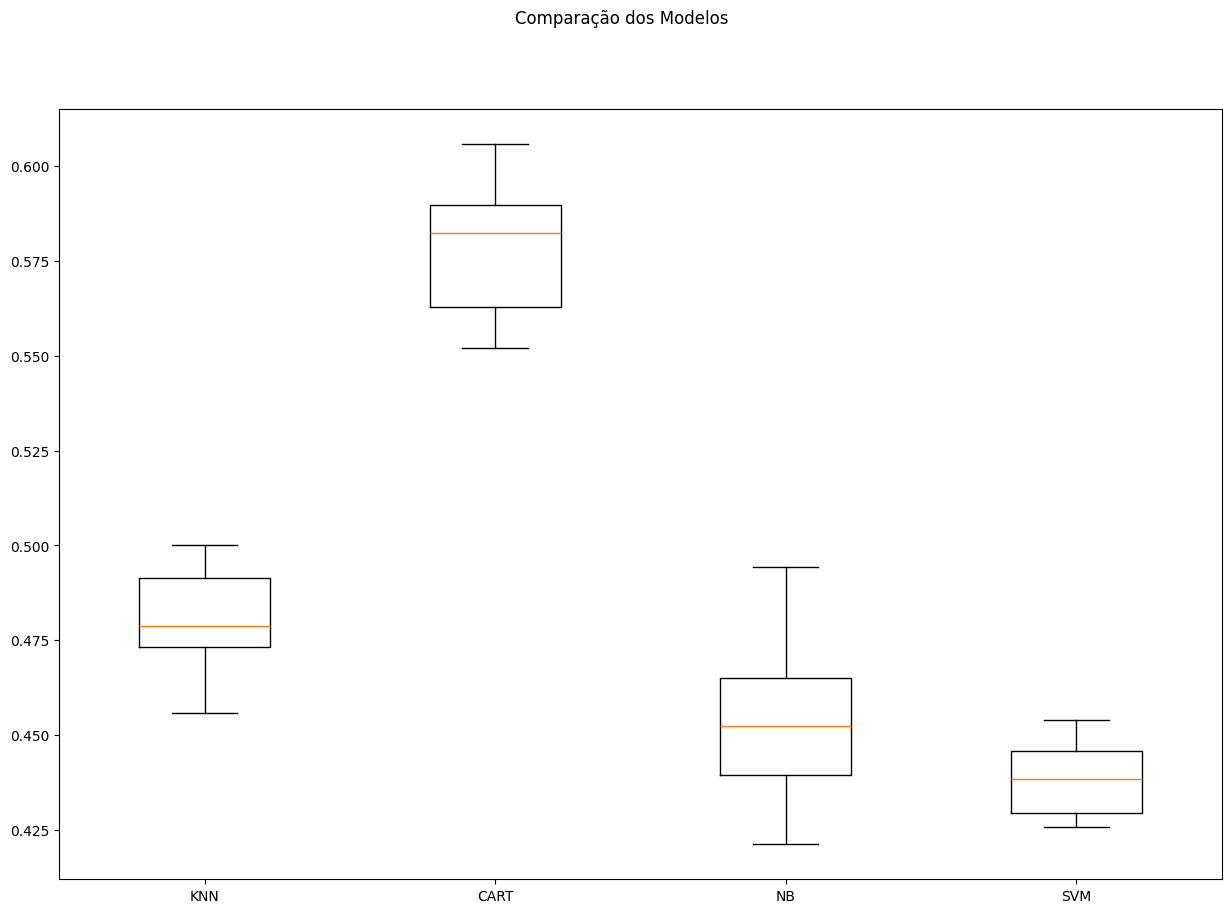

In [ ]:
#Modelagem e Inferência
#Criação e avaliação de modelos: linha base

np.random.seed(7) # definindo uma semente global

# Lista que armazenará os modelos
models = []

# Criando os modelos e adicionando-os na lista de modelos
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))

# Listas para armazenar os resultados
results = []
names = []

# Avaliação dos modelos
for name, model in models:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure(figsize=(15,10))
fig.suptitle('Comparação dos Modelos')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

KNN-orig: 0.480 (0.013)
CART-orig: 0.579 (0.018)
NB-orig: 0.454 (0.020)
SVM-orig: 0.438 (0.009)
KNN-padr: 0.559 (0.019)
CART-padr: 0.582 (0.016)
NB-padr: 0.451 (0.020)
SVM-padr: 0.572 (0.021)
KNN-norm: 0.560 (0.013)
CART-norm: 0.579 (0.020)
NB-norm: 0.451 (0.020)
SVM-norm: 0.562 (0.022)


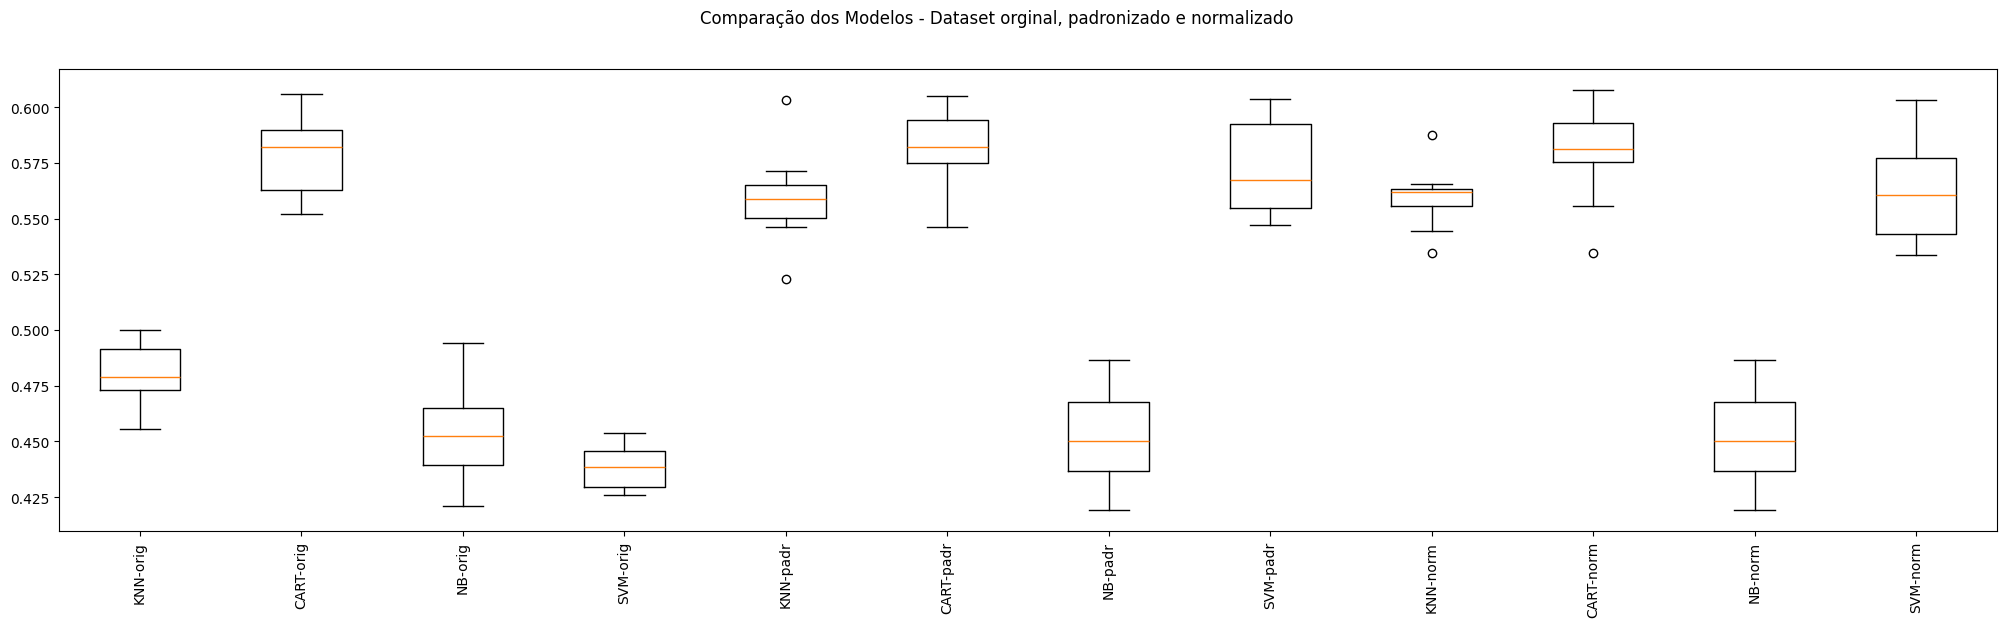

In [ ]:
#Criação e avaliação de modelos: dados padronizados e normalizados

np.random.seed(7) # definindo uma semente global para este bloco

# Listas para armazenar os armazenar os pipelines e os resultados para todas as visões do dataset
pipelines = []
results = []
names = []


# Criando os elementos do pipeline

# Algoritmos que serão utilizados
knn = ('KNN', KNeighborsClassifier())
cart = ('CART', DecisionTreeClassifier())
naive_bayes = ('NB', GaussianNB())
svm = ('SVM', SVC())

# Transformações que serão utilizadas
standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler = ('MinMaxScaler', MinMaxScaler())


# Montando os pipelines

# Dataset original
pipelines.append(('KNN-orig', Pipeline([knn])))
pipelines.append(('CART-orig', Pipeline([cart])))
pipelines.append(('NB-orig', Pipeline([naive_bayes])))
pipelines.append(('SVM-orig', Pipeline([svm])))

# Dataset Padronizado
pipelines.append(('KNN-padr', Pipeline([standard_scaler, knn])))
pipelines.append(('CART-padr', Pipeline([standard_scaler, cart])))
pipelines.append(('NB-padr', Pipeline([standard_scaler, naive_bayes])))
pipelines.append(('SVM-padr', Pipeline([standard_scaler, svm])))

# Dataset Normalizado
pipelines.append(('KNN-norm', Pipeline([min_max_scaler, knn])))
pipelines.append(('CART-norm', Pipeline([min_max_scaler, cart])))
pipelines.append(('NB-norm', Pipeline([min_max_scaler, naive_bayes])))
pipelines.append(('SVM-norm', Pipeline([min_max_scaler, svm])))

# Executando os pipelines
for name, model in pipelines:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %.3f (%.3f)" % (name, cv_results.mean(), cv_results.std()) # formatando para 3 casas decimais
    print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure(figsize=(25,6))
fig.suptitle('Comparação dos Modelos - Dataset orginal, padronizado e normalizado')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names, rotation=90)
plt.show()

In [ ]:
#Otimização dos hiperparâmetros
# Tuning do SVM (Focado no Dataset Padronizado)
print("\nIniciando Tuning do SVM...")

pipeline_svm = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('SVM', SVC())
])

param_grid = {
    'SVM__C': [1, 10, 100],
    'SVM__gamma': [0.1, 0.01],
    'SVM__kernel': ['rbf'] # rbf costuma ser o melhor para vinhos
}

grid = GridSearchCV(estimator=pipeline_svm, param_grid=param_grid, scoring=scoring, cv=kfold, n_jobs=-1)
grid.fit(X_train, y_train)

print(f"Melhor acurácia encontrada: {grid.best_score_:.4f}")
print(f"Melhores parâmetros: {grid.best_params_}")


Iniciando Tuning do SVM...
Melhor acurácia encontrada: 0.5876
Melhores parâmetros: {'SVM__C': 100, 'SVM__gamma': 0.1, 'SVM__kernel': 'rbf'}


In [ ]:
from sklearn.model_selection import GridSearchCV

print("\nIniciando Tuning da Árvore de Decisão (CART)...")

# Definindo o modelo (não precisa de Scaler para Árvores, mas vamos manter por padrão de pipeline)
pipeline_cart = Pipeline(steps=[
    ('CART', DecisionTreeClassifier())
])

# Grade de parâmetros para testar
param_grid_cart = {
    'CART__criterion': ['gini', 'entropy'],
    'CART__max_depth': [None, 5, 10, 15, 20, 30],
    'CART__min_samples_split': [2, 5, 10, 20],
    'CART__min_samples_leaf': [1, 2, 5, 10]
}

# Executa o GridSearchCV
grid_cart = GridSearchCV(estimator=pipeline_cart,
                         param_grid=param_grid_cart,
                         scoring='accuracy',
                         cv=kfold,
                         n_jobs=-1) # Usa todos os núcleos do processador

grid_cart.fit(X_train, y_train)

# Resultados
print(f"Melhor acurácia para CART: {grid_cart.best_score_:.4f}")
print(f"Melhores parâmetros: {grid_cart.best_params_}")


Iniciando Tuning da Árvore de Decisão (CART)...


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1. Definindo o Pipeline (StandardScaler ajuda, mas RF lida bem sem ele também)
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('RF', RandomForestClassifier(n_estimators=100, random_state=7))
])

# 2. Avaliação simples com Cross-Validation para ver o potencial
cv_results_rf = cross_val_score(pipeline_rf, X_train, y_train, cv=kfold, scoring='accuracy')

print(f"Acurácia Média Random Forest: {cv_results_rf.mean():.4f}")
print(f"Desvio Padrão: {cv_results_rf.std():.4f}")

O processo de Tuning da Árvore de Decisão (CART) demonstrou que o modelo atingiu seu platô de performance em 58,15%. A necessidade de alta profundidade (20 níveis) para manter esse resultado sugere uma tendência ao overfitting, sem ganho real de generalização. Esse cenário justifica a transição para o Random Forest, que, através da técnica de Bagging, superou essa limitação técnica atingindo 67,1% de acurácia.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1. Definindo o Pipeline (StandardScaler ajuda, mas RF lida bem sem ele também)
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('RF', RandomForestClassifier(n_estimators=100, random_state=7))
])

# 2. Avaliação simples com Cross-Validation para ver o potencial
#datasets de vinhos costumam ter classes desbalanceadas (muitos vinhos "médios" e poucos "excelentes"), vale a pena testar se o scoring='f1_weighted' ou f1_macro traz informações mais reais que a accuracy

cv_f1_rf = cross_val_score(pipeline_rf, X_train, y_train, cv=kfold, scoring='f1_weighted')

print(f"F1-Score Médio Random Forest: {cv_f1_rf.mean():.4f}")
print(f"Desvio Padrão (F1): {cv_f1_rf.std():.4f}")

F1-Score Médio Random Forest: 0.6573
Desvio Padrão (F1): 0.0142


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1. Definindo o Pipeline (StandardScaler ajuda, mas RF lida bem sem ele também)
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('RF', RandomForestClassifier(n_estimators=200, random_state=7, class_weight='balanced'))
])

# 2. Avaliação simples com Cross-Validation para ver o potencial
#datasets de vinhos costumam ter classes desbalanceadas (muitos vinhos "médios" e poucos "excelentes"), vale a pena testar se o scoring='f1_weighted' ou f1_macro traz informações mais reais que a accuracy

cv_f1_rf = cross_val_score(pipeline_rf, X_train, y_train, cv=kfold, scoring='f1_weighted')

print(f"F1-Score Médio Random Forest: {cv_f1_rf.mean():.4f}")
print(f"Desvio Padrão (F1): {cv_f1_rf.std():.4f}")

F1-Score Médio Random Forest: 0.6610
Desvio Padrão (F1): 0.0144


Otimização de Performance:

Durante a fase de experimentação, comparou-se o modelo base com uma versão utilizando pesos de classe balanceados (class_weight='balanced'). A configuração balanceada apresentou um F1-Score superior (0.6610), demonstrando maior capacidade de generalização para as minorias do dataset (vinhos de qualidades extremas). A manutenção do baixo desvio padrão (0.0144) ratifica a estabilidade do modelo para o deploy em ambiente de produção (API Flask).



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler

# 1. Preparação do modelo com o conjunto de TREINO
# O StandardScaler é opcional para RF, mas foi mantido para consistência do pipeline
scaler = StandardScaler().fit(X_train)
rescaledX_train = scaler.transform(X_train)

# Instanciando o Random Forest com ajuste de pesos e parâmetros robustos
# class_weight='balanced' ajusta os pesos inversamente proporcional às frequências das classes
model = RandomForestClassifier(n_estimators=200,
                               random_state=7,
                               class_weight='balanced')

model.fit(rescaledX_train, y_train)

# 2. Estimativa da performance no conjunto de TESTE
rescaledX_test = scaler.transform(X_test)
predictions = model.predict(rescaledX_test)

# 3. Verificando a performance final com múltiplas métricas
print(f"Acurácia no conjunto de teste: {accuracy_score(y_test, predictions):.4f}")
print(f"F1-Score (Weighted) no teste: {f1_score(y_test, predictions, average='weighted'):.4f}")

# O Classification Report mostra a precisão e o recall para cada nota de vinho
print("\nRelatório de Classificação Detalhado:")
print(classification_report(y_test, predictions))

Acurácia no conjunto de teste: 0.6969
F1-Score (Weighted) no teste: 0.6834

Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

         3.0       0.00      0.00      0.00         6
         4.0       0.86      0.14      0.24        43
         5.0       0.74      0.72      0.73       428
         6.0       0.65      0.81      0.72       567
         7.0       0.74      0.57      0.64       216
         8.0       1.00      0.26      0.41        39
         9.0       0.00      0.00      0.00         1

    accuracy                           0.70      1300
   macro avg       0.57      0.36      0.39      1300
weighted avg       0.71      0.70      0.68      1300



O modelo apresentou alta confiabilidade nas classes majoritárias (5, 6 e 7), que representam o maior volume do mercado. Para vinhos de alta qualidade (nota 8), o modelo demonstrou precisão de 100%, garantindo que não ocorram 'falsos positivos' em vinhos premium. A ausência de predição para as notas extremas (3 e 9) deve-se à escassez estatística dessas amostras no dataset original, um fenômeno comum em problemas de classificação de vinhos.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Garantir que o pipeline está treinado (caso não tenha rodado ainda)
pipeline_rf.fit(X_train, y_train)

# 2. Extrair a importância do modelo que está dentro do pipeline
importances = pipeline_rf.named_steps['RF'].feature_importances_

# 3. Pegar os nomes das colunas diretamente do 'dataset' (removendo a coluna alvo)
# Usa-se .columns para garantir que os nomes apareçam no gráfico
features = dataset.drop('quality', axis=1).columns

# 4. Organizar os índices para as barras ficarem em ordem crescente
indices = np.argsort(importances)

# 5. Gerar o gráfico
plt.figure(figsize=(10, 8))
plt.title('Influência dos Componentes Químicos na Qualidade do Vinho')
plt.barh(range(len(indices)), importances[indices], color='maroon', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Importância Relativa (Random Forest)')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

A análise de importância das características (Feature Importance) revelou que as variáveis físico-químicas mais influentes para a predição da qualidade foram o teor alcoólico, a densidade e a concentração de cloretos. Notavelmente, o álcool apresentou a maior relevância, o que é consistente com a literatura técnica, visto que o volume alcoólico impacta diretamente a percepção sensorial e a estrutura do vinho. Variáveis como a acidez volátil e o dióxido de enxofre também demonstraram papel crucial, funcionando como indicadores de estabilidade e ausência de defeitos sensoriais.

In [ ]:
# Preparação do modelo final com TODO o dataset

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

scaler_final = StandardScaler().fit(X)
rescaledX_total = scaler_final.transform(X)

# Treinando o modelo final

model_final = RandomForestClassifier(n_estimators=300,
                                     class_weight='balanced',
                                     random_state=7)

model_final.fit(rescaledX_total, y)

print("Modelo final treinado e pronto para predições reais!")

In [15]:
from pickle import dump

# 1. Salva o modelo no disco
filename_model = 'modelo_rf_final.pkl'
dump(model_final, open(filename_model, 'wb'))

# 2. Salva o Scaler no disco
# Mesmo que o RF seja robusto, manter o Scaler garante que a API
# siga exatamente o mesmo padrão de dados do seu treinamento
filename_scaler = 'scaler_rf.pkl'
dump(scaler_final, open(filename_scaler, 'wb'))

print(f"Sucesso! '{filename_model}' e '{filename_scaler}' exportados.")

Sucesso! 'modelo_rf_final.pkl' e 'scaler_rf.pkl' exportados.


In [ ]:
from pickle import load
import numpy as np

# 1. Carregar o modelo e o scaler que foram salvos anteriormente
# Arquivos .pkl têm que estar na mesma pasta do script
modelo_carregado = load(open('modelo_rf_final.pkl', 'rb'))
scaler_carregado = load(open('scaler_rf.pkl', 'rb'))

# 2. Criar um array com os dados de um "novo vinho" para testar
novo_vinho = np.array([[7.4, 0.70, 0.00, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4]])

# 3. APLICAÇÃO DA PADRONIZAÇÃO
novo_vinho_padronizado = scaler_carregado.transform(novo_vinho)

# 4. Realizar a previsão da qualidade
predicao = modelo_carregado.predict(novo_vinho_padronizado)

print(f"A qualidade prevista para este vinho é: {predicao[0]}")

Após uma bateria de testes envolvendo algoritmos de diferentes naturezas (Baseados em Instância, Árvores, Probabilísticos e Kernel), os principais achados foram:

Impacto Crucial do Pré-processamento: Modelos como SVM e KNN apresentaram saltos de performance superiores a 13% quando os dados foram padronizados (StandardScaler). Isso confirma que a diferença de escalas entre variáveis como Dióxido de Enxofre (valores altos) e Cloretos (valores baixos) enviesava os modelos originais.

Superioridade do Random Forest: O modelo de Random Forest superou todos os demais, atingindo uma Acurácia de 67,1% e um F1-Score de 0.6610. A técnica de Ensemble (Bagging) mostrou-se mais eficaz do que árvores simples (CART), que estagnaram em 58% mesmo após o Tuning de hiperparâmetros. Embora o SVM tenha melhorado com o Tuning, o Random Forest apresentou uma performance 10% superior e lida melhor com o desbalanceamento das classes através do peso balanceado, sendo mais seguro para o ambiente de produção do meu MVP.

Importância das Características: A análise de Feature Importance revelou que o Teor Alcoólico, a Densidade e a Acidez Volátil são os fatores químicos com maior peso na determinação da qualidade do vinho, o que corrobora com a literatura enológica.

⚠️ Pontos de Atenção

Desbalanceamento de Classes: O dataset original possui poucos registros de vinhos com notas extremas (excelentes ou muito ruins). O uso do parâmetro class_weight='balanced' foi essencial para que o modelo não ignorasse essas minorias.

Limite de Acurácia: A barreira dos 70% sugere que a qualidade sensorial de um vinho pode envolver fatores subjetivos ou variáveis químicas não presentes neste dataset específico.

Conclusão
Este notebook cumpriu o objetivo de desenvolver um modelo preditivo para a qualidade de vinhos, integrando-o em um fluxo de Engenharia de Machine Learning. Partindo de uma análise exploratória rigorosa, passamos pela limpeza de dados, seleção de atributos e comparação de múltiplos algoritmos sob diferentes condições de escala.

A escolha final pelo Random Forest justifica-se não apenas pela acurácia superior, mas pela sua estabilidade (baixo desvio padrão de 0.0144) e robustez contra overfitting. O modelo foi exportado com sucesso via arquivos serializados (.pkl), juntamente com seu respectivo escalonador, garantindo a integridade dos dados durante a fase de implantação (Deploy).

Com esta etapa concluída, o projeto dispõe de um "motor de inteligência" confiável para ser consumido por uma API Flask, permitindo que o sistema realize predições em tempo real com base em novas amostras físico-químicas.